In [1]:
# Include installs here in format !pip install xxxxx. Comment out if not needed for you
!pip install mlflow
!pip install seaborn
!pip install pandas
!pip install kagglehub[pandas-datasets]

In [2]:
# Include Includes here
from concurrent.futures import ThreadPoolExecutor, as_completed
import gc
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import sys
import kagglehub
from sklearn.calibration import CalibratedClassifierCV
from kagglehub import KaggleDatasetAdapter
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, auc
)
import mlflow
import mlflow.sklearn
from datetime import datetime
import logging

c:\Users\luism\anaconda3\envs\course-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Important
- Use MLFLOW for tracking

# 0. Problem Framing
We are using the dataset linked [here](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). This dataset has a feature called `class` which contains the targets for our project. In this feature, an **anomaly** is defined as an instance of credit card fraud and is assigned a value of `1`. All non-anomalous transactions are assigned a value of `0`.

To ensure the best possible results given the information available, we will be using **supervised learning** with the `class` feature as our target variable. We will train three models, `Moving Average Bands`, `kNN`, and `SVM`. These models were selected specifically to compare the performance of statistical, distance-based, and machine learning approaches to anomaly detection. 

The contents of this dataset are wholly numeric results of PCA, except for `amount` and `time `. The original features are not provided to maintain privacy. The data is heavily imbalanced. As such, we will use primarily precision-recall curve for analysis of performance as the confusion matrix will not provide useful results. 
As per the dataset page, the non - PCA features are as follows:

> "Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning."


## Method Discussion and Justification


## Moving Average Bands
-----
### Advantages
### Disadvantages
### Why it is good for this specific problem

## kNN
-----
### Advantages
### Disadvantages
### Why it is good for this specific problem


### SVM
-----
Support vector machines are an approach based on error-based learning. 
They are typically used for classification, regression, and outlier detection.
SVM is a **discriminative** classifier. This means it finds a point/line/plane/etc which divides classes from eachother.

If you draw a decision boundary or separating hyperplane between two classes, the distance from the boundary to the nearest training instance is known as the **margin**.
This can be illustrated using dashed lines known as **margin extents**. We optimize our model by selecting the separation with the greatest margin.

Where $\gamma_i$ is the distance between the boundary and a given point, we can write: 
$$
\gamma_i = y_i(w^Tx_i+b)\quad\quad y_i \in \{-1,1\}
$$

Here, $w$ is the separating hyperplane is given by
$$
b+w^T\cdot x=0
$$

Where $w\cdot d$ is the dot product of the weights and descriptive feature values, plus the bias (intercept).
for SVM, we first need to set the negative target feature level to -1 and the positive to +1. 
The model is then made such that instances with the negative target level output $\le-1$ and positive $\ge+1$.
The in-bewteen area allows for the margin.

Our goal is thus to find $b,w$ to maximize the margin, which can be achieved my minimizing $w$:

$$
\begin{array}{rl}
\textrm{max}_{\gamma,w,b} & \gamma \\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge \gamma,\quad i=1...m\\
\end{array}
$$

$$
\begin{array}{rl}
\textrm{min}_{\gamma,w,b} & \frac{1}{2}||w||^2 \\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge 1,\quad i=1...m\\
\end{array}
$$

A **hard margin** is that which was described above - and is useful in linearly seperable problems. 
We could also consider a **soft margin**, useful in situations where this is not the case or where the hard margin produces a small margin.
In this case, misclassification is allowed and then we minimize the error therein. 
The loss of a misclassified point is called a **slack variable**. 
We can then use the following equation for our problem.
$$
\begin{array}{rl}
\textrm{min}_{\gamma,w,b} & \frac{1}{2}||w||^2 + C \sum^m_{i=1}{\xi_i}\\
\textrm{s.t.} & y_i(w^Tx_i+b) \ge 1,\quad i=1...m\\
\textrm{    } & \xi_m \geq \forall m\\
\end{array}
$$


### Advantages
They are best for high-dimensional spaces and are memory efficient. 

When handling non-linearly separable datasets, we can change the **kernel**. 
This allows us to increase the dimensionality of our problem, helping to identify hyperplanes for classification.
By adjusting  $\gamma$, we can modify how far the influence of a training point is considered. 
The higher we set it, the closer points we consider.

We can vary the hyperparamter C to dictate the level of penalty applied to misclassification. 
A small C value implies no permission for error - or a hard boundary.
A large value of C implies a greater tolerance for misclassification - or a soft boundary.

### Disadvantages
If the number of features is far greater than that of samples, we need to employ regularization to avoid overfitting.
SVMs do not provide probability estimates, instead we need a five-fold cross validation to do this.

SVM is also very sensitive to feature scaling, and we should ensure all features are normalized or standardized.

### Why it is good for this specific problem
For anomaly detection, SVM will generate a decision function that assigns new points a decision score based on how anomalous they are.
By choosing the correct kernel and optimizing our hyperparameters - we are able to create a decision boundary should enclose the majority of the data.

Things to do for pretreating data
- check missing values
- oversample minority class
- split into train and test sets with stratified sampling using sklearn using ten fold cross validation so 10/90


## Data Understanding

# 1.Data Preparation

In [3]:
def get_df():
    # make it so we dont need the local zip
    file_path = "creditcard.csv"
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "mlg-ulb/creditcardfraud",
        file_path,
        pandas_kwargs={"encoding": "cp1252"}
    )
    return df

In [4]:
def get_df():
    file_path = "creditcard.csv"
    df = pd.read_csv(file_path)
    return df

In [5]:
df = get_df()

# df = pd.read_csv("creditcard.csv")
rows = df.shape[0] #calculate number of rows
features = df.columns #features
n_features = df.shape[1] #number of features

print(f"Number of samples: {rows}")
print(f"Number of features: {n_features}")

print("\n\033[1m" + "Data types of each feature:" + "\033[0m")
for col in df.columns:
    print(f"\t{col:<10} = {df[col].dtype}")

#identify anomalies:

#find missing values in each feature:
if (df.isnull().any().any()): # If there are actually any missing values
    print(f"\nFeatures with missing values\n:")
    for feat in features:
        missing_nan = df[feat].isnull().sum() #adds all missing values in that column
        if missing_nan > 0:
            missing_per = (missing_nan/rows)*100 #finds the percentage
            print(f"{feat}: NaN = {missing_nan}, NaN% = {missing_per:.2f}%")
else:
    print("There are no missing values")

#find features with only one category (which provides no valuable information):
if (len(df.columns[df.nunique() == 1])>0): # If there are actually any
    print(f"\nFeatures with only one category:\n")
    for feat in features:
        if df[feat].nunique() == 1:
            print(f"{feat}")

df.head()

Number of samples: 284807
Number of features: 31

Data types of each feature:
	Time       = float64
	V1         = float64
	V2         = float64
	V3         = float64
	V4         = float64
	V5         = float64
	V6         = float64
	V7         = float64
	V8         = float64
	V9         = float64
	V10        = float64
	V11        = float64
	V12        = float64
	V13        = float64
	V14        = float64
	V15        = float64
	V16        = float64
	V17        = float64
	V18        = float64
	V19        = float64
	V20        = float64
	V21        = float64
	V22        = float64
	V23        = float64
	V24        = float64
	V25        = float64
	V26        = float64
	V27        = float64
	V28        = float64
	Amount     = float64
	Class      = int64
There are no missing values


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


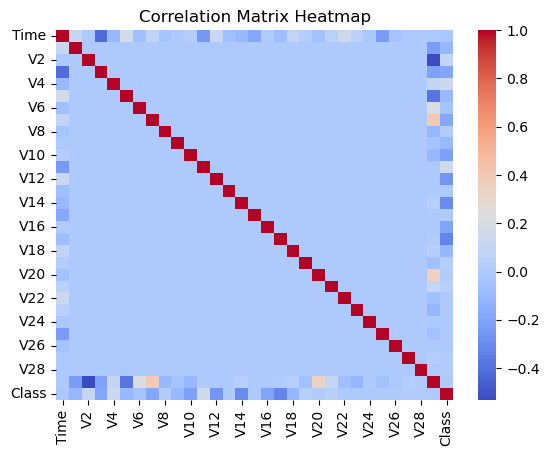

In [6]:
# Correlation matrix
correlation_matrix = df.corr()

sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

A low correlation among features generally implies that the variables are not strongly linearly related to each other. 
This also means that each feature is contributing different, non-redundant information.

To compensate for the severe class imbalance in the data, we will be using a **stratified 5-fold cross validation**. 
This will ensure that each training and validation split preserves the original class distribution.
This ensures that anomalies are represented in every fold, allowing for more reliable evaluation of the model’s detection performance
> MAYBE ADD MORE TO THIS?

## 1.1. Moving Average Bands

## 1.2. kNN

In [7]:
# Separate features and labels
X = df.drop("Class", axis=1)
y = df["Class"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1.3. SVM

Robust scaling is used when outliers are real, but scaling is still necessary. 
In the case of supervised anomaly detection, we do not want to remove out anomalies. 
As such, we will use robust scaling - given by:
$$
x'=\frac{x-median(x)}{IQR(x)}
$$

In [10]:
def SVM_preprocess(d):
    X = d.iloc[:, :-1]
    y = d.iloc[:, -1]

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

    return X_scaled,y

# 2. Detection Methods


## 2.1. Moving Average Bands

## 2.2. kNN

In [11]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Use k neighbors
k = 5

# Fit NearestNeighbors (unsupervised distance model)
nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
nn.fit(X_train_scaled)

# Compute distances to k neighbors
distances, _ = nn.kneighbors(X_test_scaled)

# Anomaly score = average distance to k neighbors
anomaly_scores = distances.mean(axis=1)

## 2.3. SVM

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
import pandas as pd

def SVM_preprocess(d):
    X = d.iloc[:, :-1].copy()
    y = d.iloc[:, -1].copy()
    return X, y

In [13]:
from sklearn.svm import OneClassSVM
import time

def run_one_class_svm(
    d,
    test_size=0.2,
    nu=0.01,
    max_train_normal=20000,
    random_state=42,
    threshold=None
):
    # Split features and labels
    X, y = SVM_preprocess(d)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # Train only on normal transactions
    X_train_normal = X_train[y_train == 0].copy()

    print(f"Total training samples: {len(X_train)}")
    print(f"Normal training samples before sampling: {len(X_train_normal)}")
    print(f"Fraud samples in test set: {int((y_test == 1).sum())}")

    # Speed-up: sample normal training data if too large
    if len(X_train_normal) > max_train_normal:
        X_train_normal = X_train_normal.sample(
            n=max_train_normal,
            random_state=random_state
        )
        print(f"Normal training samples after sampling: {len(X_train_normal)}")

    # Scale using only normal training data
    scaler = RobustScaler()
    X_train_normal_scaled = scaler.fit_transform(X_train_normal)
    X_test_scaled = scaler.transform(X_test)

    # One-Class SVM
    model = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)

    # Train
    t0 = time.time()
    model.fit(X_train_normal_scaled)
    t1 = time.time()

    # Higher score = more anomalous
    anomaly_scores = -model.decision_function(X_test_scaled).ravel()

    # Predictions
    if threshold is None:
        print("Using default One-Class SVM threshold of 0")
        y_pred_raw = model.predict(X_test_scaled)
        y_pred = np.where(y_pred_raw == -1, 1, 0)
    else:
        print(f"Using custom threshold = {threshold:.6f}")
        y_pred = (anomaly_scores >= threshold).astype(int)

    return {
        "model": model,
        "scaler": scaler,
        "X_test_scaled": X_test_scaled,
        "y_test": y_test,
        "anomaly_scores": anomaly_scores,
        "y_pred": y_pred,
        "training_time": t1 - t0
    }

# 3. Threshold Optimization
- Optimizing to reduce false negatives
- Confusion matrix less important here
- AUC more important
- Analyze anomaly score distributions
- Select and justify detection threshold
- Perform sensitivity analysis on threshold selection
- Priority = recall

## 3.1. Moving Average Bands

## 3.2. kNN

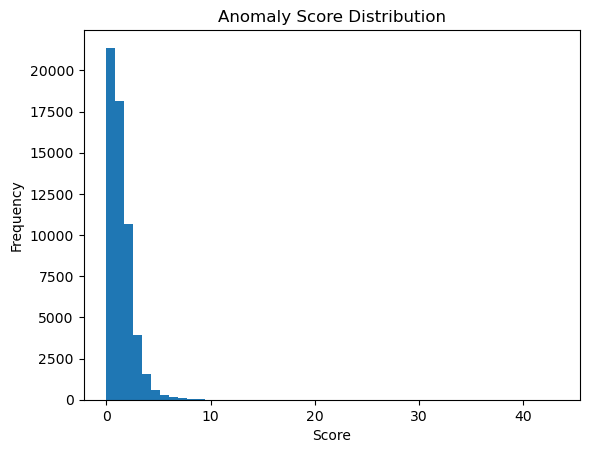

In [14]:
import matplotlib.pyplot as plt

plt.hist(anomaly_scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

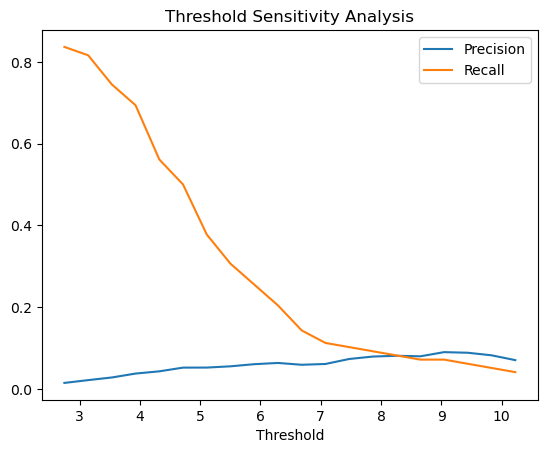

In [15]:
thresholds = np.linspace(np.percentile(anomaly_scores, 90),
                         np.percentile(anomaly_scores, 99.9), 20)

from sklearn.metrics import precision_score, recall_score

precision_list = []
recall_list = []

for t in thresholds:
    y_temp = (anomaly_scores > t).astype(int)
    precision_list.append(precision_score(y_test, y_temp))
    recall_list.append(recall_score(y_test, y_temp))

plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Threshold Sensitivity Analysis")
plt.show()

## 3.3. SVM

In [16]:
results = run_one_class_svm(
    df,
    test_size=0.2,
    nu=0.01,
    max_train_normal=20000,
    random_state=42,
    threshold=None
)

Total training samples: 227845
Normal training samples before sampling: 227451
Fraud samples in test set: 98
Normal training samples after sampling: 20000
Using default One-Class SVM threshold of 0


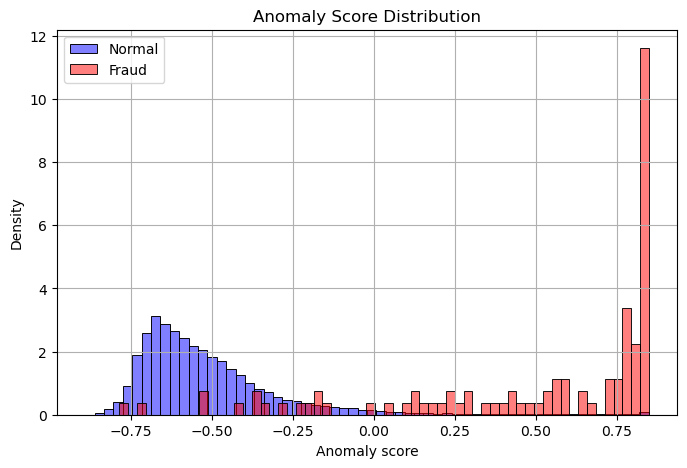

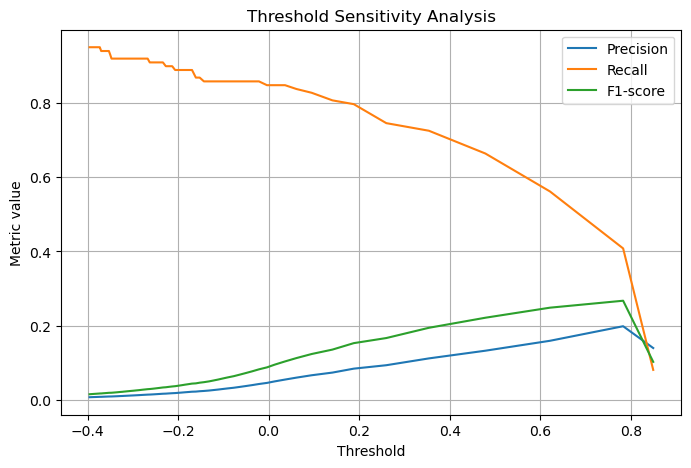

In [17]:
# Anomaly score distributions plot:  
scores = results["anomaly_scores"]
y_test = np.array(results["y_test"])

plt.figure(figsize=(8, 5))
sns.histplot(scores[y_test == 0], color="blue", label="Normal", stat="density", bins=60, alpha=0.5)
sns.histplot(scores[y_test == 1], color="red", label="Fraud", stat="density", bins=60, alpha=0.5)

plt.xlabel("Anomaly score")
plt.ylabel("Density")
plt.title("Anomaly Score Distribution")
plt.legend()
plt.grid(True)
plt.show()

# Sensitivity analysis on threshold selection:
thresholds = np.quantile(scores, np.linspace(0.80, 0.999, 80))

rows = []

for t in thresholds:
    y_pred = (scores >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    alert_rate = y_pred.mean()

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "alert_rate": alert_rate,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

results_df = pd.DataFrame(rows)

plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold Sensitivity Analysis")
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluation
- Precision, Recall, F1-score
- ROC curve and PR curve
- Confusion matrix at selected threshold
- False positive rate analysis

## 4.1. MAB

## 4.2. kNN

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

# Example threshold (top 2% anomalies)
threshold = np.percentile(anomaly_scores, 98)

y_pred = (anomaly_scores > threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[55776  1088]
 [   46    52]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.05      0.53      0.08        98

    accuracy                           0.98     56962
   macro avg       0.52      0.76      0.54     56962
weighted avg       1.00      0.98      0.99     56962



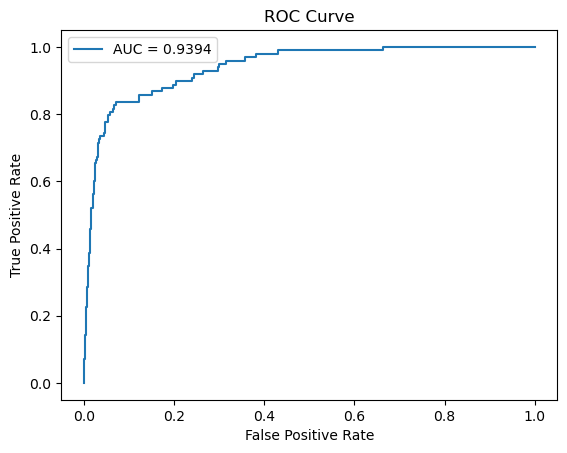

In [19]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, anomaly_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

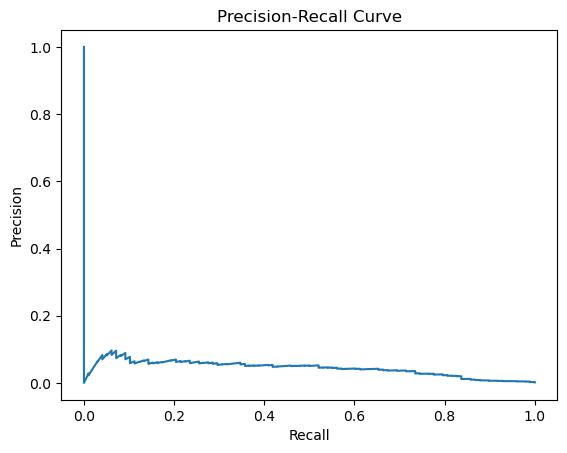

In [20]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, anomaly_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [21]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fpr_value = fp / (fp + tn)
print("False Positive Rate:", fpr_value)

False Positive Rate: 0.019133370849746763


SVM:

In [22]:
results = run_one_class_svm(
    df,
    test_size=0.2,
    nu=0.01,
    max_train_normal=20000,
    random_state=42,
    threshold=0.8
)

y_test = np.array(results["y_test"])
y_pred = np.array(results["y_pred"])
scores = np.array(results["anomaly_scores"])
X_test_scaled = results["X_test_scaled"]
print(np.unique(y_pred, return_counts=True))

Total training samples: 227845
Normal training samples before sampling: 227451
Fraud samples in test set: 98
Normal training samples after sampling: 20000
Using custom threshold = 0.800000
(array([0, 1]), array([56779,   183]))


[[56717   147]
 [   62    36]]


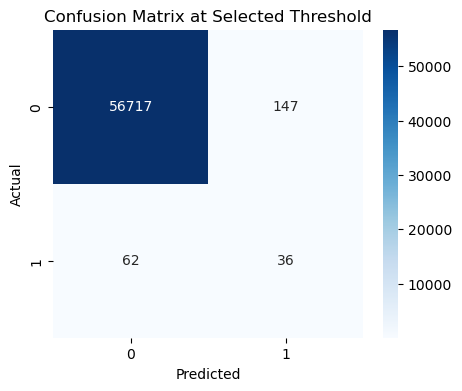

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.20      0.37      0.26        98

    accuracy                           1.00     56962
   macro avg       0.60      0.68      0.63     56962
weighted avg       1.00      1.00      1.00     56962

False Positive Rate: 0.0026
True Positive Rate (Recall): 0.3673


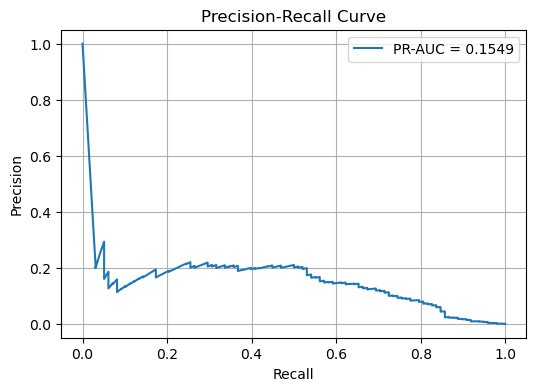

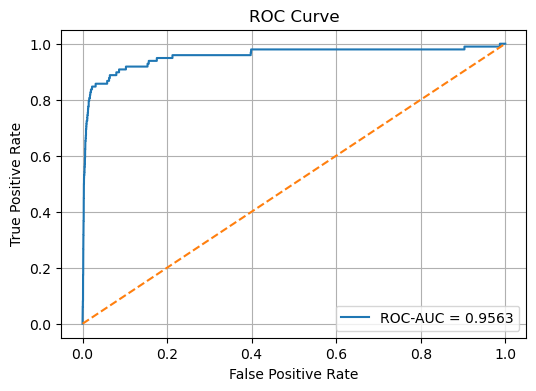

In [23]:
# Confusion matrix:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix at Selected Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred, zero_division=0))

# FPR and Recall analysis:
tn, fp, fn, tp = cm.ravel()

fpr_value = fp / (fp + tn)
recall_value = tp / (tp + fn)

print(f"False Positive Rate: {fpr_value:.4f}")
print(f"True Positive Rate (Recall): {recall_value:.4f}")

# PR curve:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, scores)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

# ROC curve:
fpr_curve, tpr_curve, _ = roc_curve(y_test, scores)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(6, 4))
plt.plot(fpr_curve, tpr_curve, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

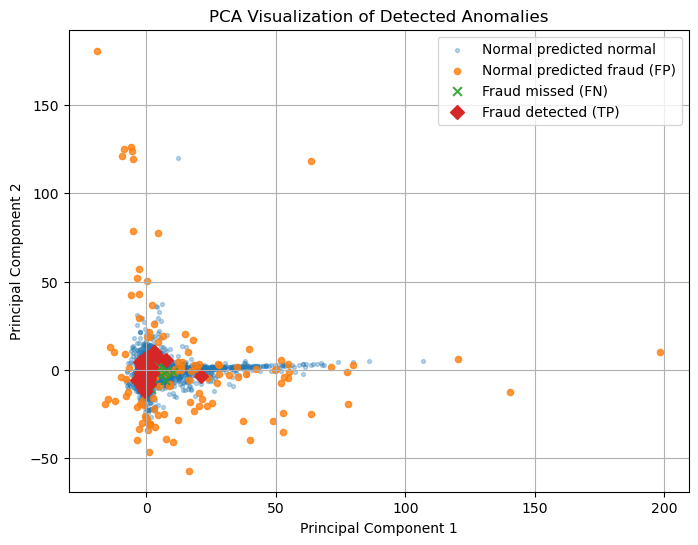

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduce test data to 2D
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8, 6))

# True normals predicted as normal
mask_tn = (y_test == 0) & (y_pred == 0)
plt.scatter(
    X_test_pca[mask_tn, 0], X_test_pca[mask_tn, 1],
    s=8, alpha=0.3, label="Normal predicted normal"
)

# True normals predicted as fraud (false positives)
mask_fp = (y_test == 0) & (y_pred == 1)
plt.scatter(
    X_test_pca[mask_fp, 0], X_test_pca[mask_fp, 1],
    s=20, alpha=0.8, label="Normal predicted fraud (FP)"
)

# True fraud predicted as normal (false negatives)
mask_fn = (y_test == 1) & (y_pred == 0)
plt.scatter(
    X_test_pca[mask_fn, 0], X_test_pca[mask_fn, 1],
    s=40, alpha=0.9, marker="x", label="Fraud missed (FN)"
)

# True fraud predicted as fraud (true positives)
mask_tp = (y_test == 1) & (y_pred == 1)
plt.scatter(
    X_test_pca[mask_tp, 0], X_test_pca[mask_tp, 1],
    s=50, alpha=1.0, marker="D", label="Fraud detected (TP)"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Detected Anomalies")
plt.legend()
plt.grid(True)
plt.show()

## 4.3. Isolation Forest

# 5. Interperabiltiy

# Reflection
- Trade-offs in threshold selection
- Impact of imbalance
- Failure scenarios in production
- Monitoring and retraining strategy
- Logged experiments
- Discussion of production risks and monitoring

Smaple test.